# LoRA Fine-tune Gemma 4 E2B — Resume-Job Matcher
Runs on Colab A100 (40 GB).

**Changes from v1:**
- ❌ Removed Optuna hyperparameter search (biggest speed-up)
- ✅ Best params baked in directly
- ✅ `lora_dropout=0.05` added (was 0 — fixes overfitting)
- ✅ `target_modules` narrowed to `q_proj, v_proj` (reduces capacity / overfit risk)
- ✅ `weight_decay=0.05` added for L2 regularization
- ✅ Early stopping added — auto-restores best checkpoint (catches your ~500-step peak)
- ✅ `load_in_4bit=False` kept — BF16 is correct for A100 40GB with a 2B model

In [1]:
# Cell 1 — Install
# Install Unsloth directly from GitHub to bypass the latest pip dependency conflicts
%pip install --quiet "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
%pip install --quiet --upgrade unsloth_zoo
%pip install --quiet --upgrade wandb protobuf
%pip install --quiet datasets trl

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 8.5 MB/s 

In [2]:
# Cell 2 — Mount Drive and set data path
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/finetune_data'

Mounted at /content/drive


In [3]:
# Cell 3 — Load model + apply LoRA
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="google/gemma-4-e2b-it",
    max_seq_length=3072,
    load_in_4bit=False,  # BF16 full precision — A100 has 40GB, no need to quantize a 2B model
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,                # Increased from 8 — more capacity to learn scoring/classification
    lora_alpha=32,       # Keep at 2x rank
    lora_dropout=0.05,
    target_modules=[     # Full attention + MLP — needed for nuanced judgment tasks
        "q_proj", "k_proj", "v_proj", "o_proj",   # Attention
        "gate_proj", "up_proj", "down_proj",        # MLP
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
)
print("Model loaded and LoRA applied.")


In [4]:
# Cell 4 — Load dataset
import os
from datasets import load_dataset

ds = load_dataset("json", data_files={
    "train": os.path.join(DATA_DIR, "train.jsonl"),
    "validation": os.path.join(DATA_DIR, "val.jsonl"),
})
print(ds)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 9000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 997
    })
})


In [5]:
# Cell 5 — Verify sequence lengths against budget (sanity check before training)
import numpy as np

sample = ds["train"].select(range(min(500, len(ds["train"]))))
tok = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
lengths = [len(tok.encode(ex["text"])) for ex in sample if ex["text"]]
print(f"median={int(np.median(lengths))}  p95={int(np.percentile(lengths, 95))}  "
      f"p99={int(np.percentile(lengths, 99))}  max={max(lengths)}")
over = sum(1 for l in lengths if l > 3072)
print(f"{over}/{len(lengths)} sample rows exceed 3072 tokens")

median=1467  p95=1602  p99=1647  max=1766
0/500 sample rows exceed 3072 tokens


In [6]:
# Cell 6 — Train (response-only loss, early stopping enabled)
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    args=SFTConfig(
        dataset_text_field="text",
        max_seq_length=3072,

        # --- Batch / throughput ---
        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,      # Effective batch = 32

        # --- Regularization ---
        learning_rate=1e-5,
        weight_decay=0.05,
        lr_scheduler_type="cosine",
        warmup_steps=50,

        # --- Training length ---
        num_train_epochs=5,                 # Early stopping will cut short as needed

        # --- Precision ---
        bf16=True,

        # --- Logging & eval ---
        logging_steps=50,
        eval_strategy="steps",
        eval_steps=100,

        # --- Checkpointing ---
        save_strategy="steps",
        save_steps=100,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        output_dir="outputs",
        report_to="none",
    ),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Mask prompt tokens — compute loss only on the model response
trainer = train_on_responses_only(
    trainer,
    instruction_part="<start_of_turn>user\n",
    response_part="<start_of_turn>model\n",
)

trainer.train()
print("\nTraining complete. Best model loaded automatically.")


Loading state from: outputs/checkpoint-1000/trainer_state.json
Training stopped at step : 1000
Final train loss         : 0.9084
Final eval  loss         : 4.1000
Best eval   loss         : 4.1000 at step 1000


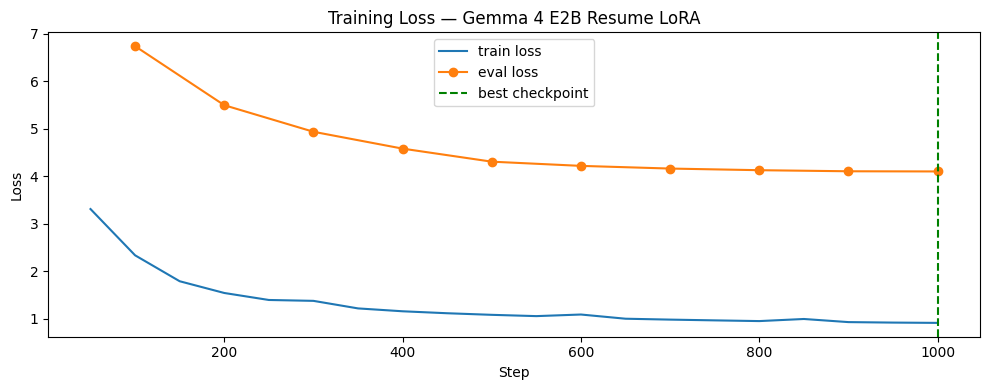

Saved training_loss.png and trainer_state.json to Drive


In [8]:
# Cell 6b — Save training loss chart + artifacts to Drive
import json, os, shutil, glob
import matplotlib.pyplot as plt

# Fix: Find the latest checkpoint directory to get the trainer_state.json
checkpoint_dirs = glob.glob("outputs/checkpoint-*")
if not checkpoint_dirs:
    raise FileNotFoundError("No checkpoint directories found in 'outputs/'. Ensure training has run long enough to save.")

latest_checkpoint = max(checkpoint_dirs, key=os.path.getmtime)
state_path = os.path.join(latest_checkpoint, "trainer_state.json")

print(f"Loading state from: {state_path}")
with open(state_path) as f:
    state = json.load(f)

train_steps, train_losses = [], []
eval_steps,  eval_losses  = [], []
for entry in state["log_history"]:
    if "loss" in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

print(f"Training stopped at step : {train_steps[-1]}")
print(f"Final train loss         : {train_losses[-1]:.4f}")
print(f"Final eval  loss         : {eval_losses[-1]:.4f}")
print(f"Best eval   loss         : {min(eval_losses):.4f} at step {eval_steps[eval_losses.index(min(eval_losses))]}")

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label="train loss")
plt.plot(eval_steps,  eval_losses,  label="eval loss", marker="o")
plt.axvline(x=eval_steps[eval_losses.index(min(eval_losses))],
            color='green', linestyle='--', label='best checkpoint')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss — Gemma 4 E2B Resume LoRA")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
os.makedirs(DRIVE_OUT, exist_ok=True)
shutil.copy("training_loss.png", DRIVE_OUT)
shutil.copy(state_path, DRIVE_OUT)
print("Saved training_loss.png and trainer_state.json to Drive")

In [9]:
# Cell 7 — Save LoRA adapter to local + Drive
import shutil, os

ADAPTER_DIR = "gemma4-e2b-resume-lora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved to {ADAPTER_DIR}/")

# Zip and copy to Drive for safekeeping
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
shutil.make_archive(os.path.join(DRIVE_OUT, ADAPTER_DIR), 'zip', ADAPTER_DIR)
print(f"Adapter zipped and saved to Drive: {DRIVE_OUT}/{ADAPTER_DIR}.zip")

Unsloth: Restored added_tokens_decoder metadata in gemma4-e2b-resume-lora/tokenizer_config.json.


Adapter saved to gemma4-e2b-resume-lora/
Adapter zipped and saved to Drive: /content/drive/MyDrive/finetune_data/gemma4-e2b-resume-lora.zip


In [10]:
# Cell 8 — Convert to GGUF and save to Drive
# Run in the SAME session as training (model is already in memory)
import os, shutil

GGUF_DIR = "gemma4-e2b-resume-gguf"
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"

# Q4_K_M: best quality/size tradeoff for inference (~1.2 GB)
# Q5_K_M: slightly sharper outputs (~1.5 GB) — uncomment if you want both
model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")
# model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q5_k_m")

os.makedirs(DRIVE_OUT, exist_ok=True)
for f in os.listdir(GGUF_DIR):
    if f.endswith(".gguf"):
        shutil.copy(os.path.join(GGUF_DIR, f), DRIVE_OUT)
        print(f"Copied {f} to Drive")

Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in gemma4-e2b-resume-gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `gemma4-e2b-resume-gguf`: 100%|██████████| 1/1 [00:24<00:00, 24.41s/it]


Successfully copied all 1 files from cache to `gemma4-e2b-resume-gguf`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:08<00:00, 68.96s/it]


Unsloth: Merge process complete. Saved to `/content/gemma4-e2b-resume-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16.gguf', 'gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16-mmproj.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.Q4_K_M.gguf', 'gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16-mmproj.gguf']


Unsloth: example usage for Multimodal LLMs: /root/.unsloth/llama.cpp/llama-mtmd-cli -m gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.Q4_K_M.gguf --mmproj gemma4-e2b-resume-gguf_gguf/gemma-4-E2B-it.BF16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image
Unsloth: Saved Ollama Modelfile to gemma4-e2b-resume-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - 

In [ ]:
# Cell 8b — GGUF conversion fallback (fresh Colab session, no retraining needed)
# Only run this if Cell 8 threw a llama.cpp compilation error
import os, shutil
from google.colab import drive
drive.mount('/content/drive')

%pip install --quiet unsloth

LORA_ZIP = "/content/drive/MyDrive/finetune_data/gemma4-e2b-resume-lora.zip"
ADAPTER_DIR = "gemma4-e2b-resume-lora"
shutil.unpack_archive(LORA_ZIP, ADAPTER_DIR)

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=ADAPTER_DIR,
    max_seq_length=3072,
    load_in_4bit=False,
)

GGUF_DIR = "gemma4-e2b-resume-gguf"
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")

os.makedirs(DRIVE_OUT, exist_ok=True)
for f in os.listdir(GGUF_DIR):
    if f.endswith(".gguf"):
        shutil.copy(os.path.join(GGUF_DIR, f), DRIVE_OUT)
        print(f"Copied {f} to Drive")

In [17]:
import shutil, os

# Source folder containing the .gguf and Modelfile
GGUF_SRC = "/content/gemma4-e2b-resume-gguf_gguf/"
DRIVE_OUT = "/content/drive/MyDrive/finetune_data"
ZIP_NAME = "gemma4-e2b-resume-gguf"

if os.path.exists(GGUF_SRC):
    print(f"Zipping GGUF artifacts from {GGUF_SRC}...")
    shutil.make_archive(os.path.join(DRIVE_OUT, ZIP_NAME), 'zip', GGUF_SRC)
    print(f"Done! Download {ZIP_NAME}.zip from your Drive.")
else:
    print(f"Error: {GGUF_SRC} not found. Check if Cell 8 or 8b finished correctly.")

Zipping GGUF artifacts from /content/gemma4-e2b-resume-gguf_gguf/...


KeyboardInterrupt: 

In [16]:
print("Initializing evaluation script...")
from unsloth import FastLanguageModel
from pydantic import BaseModel, Field, ValidationError
import json, re
import numpy as np
from collections import defaultdict

FastLanguageModel.for_inference(model)

# Mirror of matching.py MatchScore — field order must match training data
class MatchScore(BaseModel):
    rationale: str
    matching_strengths: list[str]
    skill_gaps: list[str]
    ats_keywords_missing: list[str]
    resume_improvements: list[str]
    recommended_activities: list[str] | None
    match_score: int
    experience_level_fit: str

def parse_output(text: str) -> MatchScore | None:
    try:
        return MatchScore.model_validate_json(text)
    except ValidationError:
        pass
    m = re.search(r'\{.*\}', text, re.DOTALL)
    if m:
        try:
            return MatchScore.model_validate_json(m.group())
        except ValidationError:
            pass
    return None

results = defaultdict(list)
n_eval = min(200, len(ds["validation"]))
print(f"Starting inference on {n_eval} validation samples...")

for i, example in enumerate(ds["validation"].select(range(n_eval))):
    text_content = example.get("text", "")
    if "<start_of_turn>model" not in text_content:
        continue

    parts = text_content.split("<start_of_turn>model")
    try:
        label = MatchScore.model_validate(
            json.loads(parts[-1].replace("<end_of_turn>", "").strip())
        )
    except Exception:
        continue

    prompt = parts[0] + "<start_of_turn>model\n"
    inputs = tokenizer(text=prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=1200, temperature=0.1, use_cache=True)

    generated_ids = outputs[0][len(inputs.input_ids[0]):]
    pred_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    pred = parse_output(pred_text)

    if not pred:
        print(f"[{i+1}/{n_eval}] Invalid response — schema mismatch or malformed JSON")
        print(f"  RAW: {pred_text[:150]}...")
        results["invalid"].append(1)
        continue

    results["invalid"].append(0)
    results["score_mae"].append(abs(label.match_score - pred.match_score))
    results["score_within_10"].append(int(abs(label.match_score - pred.match_score) <= 10))
    results["level_correct"].append(int(label.experience_level_fit == pred.experience_level_fit))
    print(f"[{i+1}/{n_eval}] True: {label.match_score} | Pred: {pred.match_score} | Diff: {abs(label.match_score - pred.match_score)}")

n = len(results["invalid"])
print(f"\n=== Eval Results (n={n}) ===")
if n:
    print(f"match_score MAE          : {np.mean(results['score_mae']):.1f} pts")
    print(f"match_score within 10    : {np.mean(results['score_within_10'])*100:.1f}%")
    print(f"experience_level_fit acc : {np.mean(results['level_correct'])*100:.1f}%")
    print(f"Invalid schema rate      : {np.mean(results['invalid'])*100:.1f}%")
else:
    print("No valid examples processed.")


## Loading in LM Studio on M1 Mac

### 1. Get the GGUF onto the Mac

Download `gemma4-e2b-resume-gguf.zip` from your Drive and unzip it. You'll get:
- `gemma-4-e2b-it.Q4_K_M.gguf` — ~1.2 GB, fastest, good default
- `gemma-4-e2b-it.Q5_K_M.gguf` — ~1.5 GB, slightly sharper outputs (if you exported it)

### 2. Sideload into LM Studio

1. Open LM Studio → **My Models** tab → click the models directory path to reveal it in Finder
2. Create `lmstudio-community/gemma-4-e2b-resume/` inside that folder
3. Drop the `.gguf` file(s) in
4. Hit refresh in LM Studio — model appears in the list

If your LM Studio has **Import GGUF** in the UI, use that instead.

### 3. Set the chat template (do not skip this)

In LM Studio, load the model from the **Chat** tab, open the right panel → **Prompt Template**, and pick the **Gemma** preset. If not listed, set a custom template:

```
<start_of_turn>user
{prompt}<end_of_turn>
<start_of_turn>model
```

Add `<end_of_turn>` as a **stop string**. Set **Temperature 0.1**, **Top P 0.95**.

### 4. Test prompt

```
Analyze the match between this resume and job posting.
Return a JSON object with: match_score, experience_level_fit, rationale,
matching_strengths, skill_gaps, ats_keywords_missing, resume_improvements,
recommended_activities.

RESUME:
<paste resume>

JOB POSTING:
<paste job posting>
```

Expected output: well-formed JSON with all 8 fields.

### Memory on M1

Q4_K_M at 2B uses ~1.5 GB resident + ~1 GB KV cache at 4096 ctx. Runs fine on any M1. Expect 30–50 tok/s on M1, 60–90 on M1 Pro/Max.

### If LM Studio refuses to load

Gemma 4 is recent — update LM Studio first. Verify by loading `unsloth/gemma-4-e2b-it-GGUF` from LM Studio search; if the base model loads, your fine-tune will too.